# Runge 现象：多种插值方法比较

研究函数

$$
f(x)=\frac{1}{1+x^2},\qquad x\in[-5,5].
$$

本 Notebook 比较：

1. 分段线性插值；
2. 抛物线插值
2. 全局拉格朗日插值；
3. 牛顿插值；
4. 三次样条插值；



/tmp/ipykernel_519236/3808898320.py:226: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(
/tmp/ipykernel_519236/3808898320.py:226: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(
/tmp/ipykernel_519236/3808898320.py:226: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(
/tmp/ipykernel_519236/3808898320.py:226: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "bbox_inches_restore" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(
/home/lq/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.

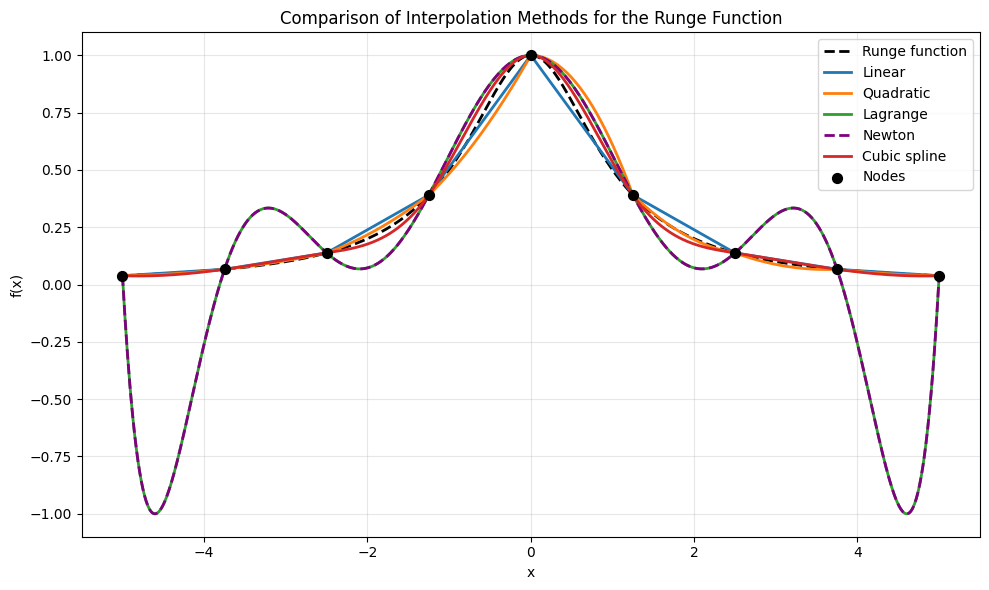

In [5]:
"""
Runge 函数插值现象比较
------------------------------------------------------------
函数：

        1
f(x)=---------
      1+x^2

区间：[-5,5]

节点数：9

比较方法：

1. 一次拉格朗日（线性）
2. 二次拉格朗日（局部）
3. 八次拉格朗日（全局）
4. 牛顿插值
5. 三次样条插值

输出：

Runge_comparison.png
"""

import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import (
    BarycentricInterpolator,
    CubicSpline
)

############################################################
# Runge函数
############################################################

def f(x):
    return 1.0/(1+x**2)

############################################################
# 一次拉格朗日（线性）
############################################################

def linear_interp(x_nodes,y_nodes,x):

    return np.interp(x,x_nodes,y_nodes)

############################################################
# 二次局部拉格朗日
############################################################

def quadratic_interp(x_nodes,y_nodes,x):

    y=np.zeros_like(x)

    for i,xx in enumerate(x):

        if xx<=x_nodes[1]:
            k=0
        elif xx>=x_nodes[-2]:
            k=len(x_nodes)-3
        else:
            k=np.searchsorted(x_nodes,xx)-1
            k=max(0,min(k-1,len(x_nodes)-3))

        xs=x_nodes[k:k+3]
        ys=y_nodes[k:k+3]

        val=0

        for j in range(3):

            Lj=1

            for m in range(3):
                if m!=j:
                    Lj*= (xx-xs[m])/(xs[j]-xs[m])

            val+=ys[j]*Lj

        y[i]=val

    return y

############################################################
# Newton差商
############################################################

def divided_difference(x,y):

    coef=np.array(y,dtype=float)

    n=len(x)

    for j in range(1,n):
        coef[j:n]=(coef[j:n]-coef[j-1:n-1])/(x[j:n]-x[0:n-j])

    return coef

############################################################
# Newton插值
############################################################

def newton_interp(x_nodes,coef,x):

    y=np.zeros_like(x)

    for i,xx in enumerate(x):

        p=coef[-1]

        for k in range(len(coef)-2,-1,-1):

            p=p*(xx-x_nodes[k])+coef[k]

        y[i]=p

    return y

############################################################
# 数据
############################################################

x_nodes=np.linspace(-5,5,9)
y_nodes=f(x_nodes)

x=np.linspace(-5,5,1000)
y_true=f(x)

############################################################
# 各种插值
############################################################

# 一次拉格朗日
y_linear=linear_interp(x_nodes,y_nodes,x)

# 二次拉格朗日
y_quad=quadratic_interp(x_nodes,y_nodes,x)

# 八次拉格朗日
lagrange=BarycentricInterpolator(x_nodes,y_nodes)
y_lagrange=lagrange(x)

# 牛顿
coef=divided_difference(x_nodes,y_nodes)
y_newton=newton_interp(x_nodes,coef,x)

# 三次样条
spline=CubicSpline(x_nodes,y_nodes)
y_spline=spline(x)

############################################################
# 绘图
############################################################

plt.figure(figsize=(10,6))

plt.plot(
    x,
    y_true,
    'k--',
    linewidth=2,
    label='Runge function'
)

plt.plot(
    x,
    y_linear,
    linewidth=2,
    label='Linear'
)

plt.plot(
    x,
    y_quad,
    linewidth=2,
    label='Quadratic'
)

plt.plot(
    x,
    y_lagrange,
    linewidth=2,
    label='Lagrange'
)

plt.plot(
    x,
    y_newton,
    '--',
    color='purple',
    linewidth=2,
    label='Newton'
)

plt.plot(
    x,
    y_spline,
    linewidth=2,
    label='Cubic spline'
)

plt.scatter(
    x_nodes,
    y_nodes,
    color='black',
    zorder=5,
    s=50,
    label='Nodes'
)

plt.title("Comparison of Interpolation Methods for the Runge Function")

plt.xlabel("x")

plt.ylabel("f(x)")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig(
    "Runge_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()